# Rank Percentile Score Validation
## Comparing three normalisation approaches for binder–decoy discrimination

**Experiment:** For each docked molecule we compute three normalised scores and compare how well each separates **known binders** from **decoys**.

| Score | Description |
|---|---|
| **Rank percentile** | Ranked within each protein, mapped 0→1 (plotted as 1 - rp_vina_score so higher = better; the stored column is 0 = best). |
| **Per-protein min-max** | Raw Vina score min-max scaled per protein (inverted, 1 = best). |
| **Z-score (decoy-referenced)** | Vina score z-scored against decoy distribution, mapped via Φ(−z) to 0→1. |

### Data sources
See `notebooks/analysis/README.md` for the full input table. In short:
* **`vinarun_scores.txt`** (`GUILD_FIGURES_DATA_DIR`) — decoys only, filtered from the large Vina case study.
* **`knownbinders_scores.txt`** (`GUILD_FIGURES_DATA_DIR`) — known binders docked fresh on the same proteins.

In [1]:
import os
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from legacy_columns import LEGACY_RENAME
from matplotlib.lines import Line2D

warnings.filterwarnings("ignore")

# ── Paths ─────────────────────────────────────────────────────────────────────
# Inputs are external (Zenodo deposit), not committed -- see notebooks/analysis/README.md.
DATA_DIR              = Path(os.environ.get("GUILD_FIGURES_DATA_DIR", "data"))
COMBINED_SCORES_PATH  = DATA_DIR / "vinarun_scores.txt"
KB_GUILD_SCORES_PATH  = DATA_DIR / "knownbinders_scores.txt"

OUT_DIR = Path(os.environ.get("GUILD_FIGURES_OUT_DIR", "np_synthetic_comparison/guild_figures"))
OUT_DIR.mkdir(parents=True, exist_ok=True)

# ── Palette ───────────────────────────────────────────────────────────────────
COLORS = {
    "decoy":          "#999999",
    "known-binder":   "#e07b39",   # orange — both strong + weak collapsed
    "strong-binder":  "#c0392b",
    "weak-binder":    "#e07b39",
    "Natural Product":"#2ecc71",
    "Synthetic":      "#3498db",
}
print("Paths configured ✓")

Paths configured ✓


In [2]:
# ── Proteins to exclude ───────────────────────────────────────────────────────
EXCLUDE_PROTEINS = {"7v6a", "8fx5", "8wrz", "8wu1", "8dzs"}

# ── Decoy subset ──────────────────────────────────────────────────────────────
# None (default) = every decoy. Set a ligand_id list or a predicate to repeat
# Figure 3 on a matched decoy panel -- see the matched-decoy cell below.
DECOY_SUBSET = None


def _apply_decoy_subset(decoys_df, subset):
    if subset is None:
        return decoys_df
    if callable(subset):
        return decoys_df[subset(decoys_df)].copy()
    return decoys_df[decoys_df["ligand_id"].isin(subset)].copy()


# ── Load scores_combined.txt — decoys only ───────────────────────────────────
combined = pd.read_csv(COMBINED_SCORES_PATH, sep="\t")
combined = combined.rename(columns=LEGACY_RENAME)
combined = combined[combined["ligand_category"] == "decoy"].copy()
combined = _apply_decoy_subset(combined, DECOY_SUBSET)
combined["group"]  = "decoy"
combined["source"] = "combined"
print(f"Decoys loaded: {len(combined):,} rows" + ("" if DECOY_SUBSET is None else " (DECOY_SUBSET applied)"))

# ── Load known-binders run scores ─────────────────────────────────────────────
if not KB_GUILD_SCORES_PATH.exists():
    raise FileNotFoundError(f"KB run not found: {KB_GUILD_SCORES_PATH}")

kb_scores = pd.read_csv(KB_GUILD_SCORES_PATH, sep="\t")
kb_scores = kb_scores.rename(columns=LEGACY_RENAME)
kb_scores["group"]  = "known-binder"
kb_scores["source"] = "kb_run"
print(f"Known-binders loaded: {len(kb_scores):,} rows")

# ── Build unified dataframe ───────────────────────────────────────────────────
unified = pd.concat([combined, kb_scores], ignore_index=True)

# ── Exclude proteins ─────────────────────────────────────────────────────────
unified["pdb_id"] = unified["protein_config_id"].str.split("-").str[0]
unified = unified[~unified["pdb_id"].isin(EXCLUDE_PROTEINS)].copy()
print(f"Unified dataset (after excluding {EXCLUDE_PROTEINS}): {len(unified):,} rows")
print(unified["group"].value_counts())

Decoys loaded: 133,000 rows
Known-binders loaded: 655 rows
Unified dataset (after excluding {'8wrz', '8fx5', '8dzs', '7v6a', '8wu1'}): 128,630 rows
group
decoy           128000
known-binder       630
Name: count, dtype: int64


In [3]:
from scipy.stats import norm as scipy_norm
from scipy.stats import percentileofscore

from guild.tools.scores import compute_rank_percentile_scores

# ── Keep only rows with a valid vina score ────────────────────────────────────
unified = unified[unified["vina_score"].notna()].copy()
print(f"Rows with valid vina score: {len(unified):,}")
print(unified["group"].value_counts())

# For the pandas-3 row-count/index-alignment check at the bottom of this cell.
_n_before = len(unified)
_index_before = unified.index.copy()

# rp_vina_score = rank / N per protein, 0->1, lower = better (rank 1 = most negative Vina).
unified = compute_rank_percentile_scores(unified, methods=["vina"])

# ── Per-protein min-max normalisation of raw Vina (comparison baseline) ───────
def _minmax_invert(grp):
    lo, hi = grp.min(), grp.max()
    return (hi - grp) / (hi - lo) if hi != lo else pd.Series(0.5, index=grp.index)

unified["vina_min_max"] = unified.groupby("protein_config_id")["vina_score"].transform(_minmax_invert)

# Per-protein decoy Vina arrays, shared by the two decoy-referenced scores below.
# Iterates the groupby object directly -- .apply() here is deprecated in pandas 2.2+.
decoy_vina_by_protein = {
    protein: sub["vina_score"].dropna().to_numpy()
    for protein, sub in unified.loc[unified["group"] == "decoy"].groupby("protein_config_id")
}

# Fraction of same-protein decoys with a worse Vina score, inverted so 1 = better
# than all decoys. Not a groupby .transform() -- it references a different set
# (decoys) than the group being scored (all molecules).
def _decoy_pct_value(protein, v):
    decoy_vina = decoy_vina_by_protein.get(protein)
    if decoy_vina is None or len(decoy_vina) < 2:
        return 0.5
    if pd.isna(v):
        return float("nan")
    return 1.0 - percentileofscore(decoy_vina, v, kind="rank") / 100.0

unified["decoy_pct"] = [
    _decoy_pct_value(p, v)
    for p, v in zip(unified["protein_config_id"], unified["vina_score"], strict=True)
]

# z-score against ALL molecules per protein, then normal CDF to [0, 1]. Lower Vina
# is better, hence -z. transform("mean"/"std") already skips NaN; sigma==0 is
# guarded explicitly since a transform can't special-case that itself.
_grouped_vina = unified.groupby("protein_config_id")["vina_score"]
_mu = _grouped_vina.transform("mean")
_sigma = _grouped_vina.transform("std")
_z = (unified["vina_score"] - _mu) / _sigma
_zscore_norm = pd.Series(scipy_norm.cdf(-_z), index=unified.index)
_degenerate = _sigma.isna() | (_sigma == 0)
unified["zscore_norm"] = _zscore_norm.where(~_degenerate, 0.5)

# Rank decoys only per protein, proportion = rank / N_decoys, then place ALL
# molecules on that decoy scale without clipping (binders beating every decoy
# land below 0; binders worse than every decoy land above 1).
def _rank_against_decoys(protein, v):
    decoy_vina = decoy_vina_by_protein.get(protein)
    if decoy_vina is None or len(decoy_vina) < 2 or pd.isna(v):
        return np.nan
    n_decoys = len(decoy_vina)
    better_than = np.sum(decoy_vina > v)
    ties = np.sum(decoy_vina == v)
    rank = n_decoys - better_than - 0.5 * ties + 0.5
    return rank / n_decoys

unified["decoy_fit_unbounded"] = [
    _rank_against_decoys(p, v)
    for p, v in zip(unified["protein_config_id"], unified["vina_score"], strict=True)
]

# Same row count, same row order as before these three columns were computed --
# the failure mode a positional (rather than per-protein-keyed) rewrite would
# have risked.
assert len(unified) == _n_before, "row count changed while computing decoy_pct/zscore_norm/decoy_fit_unbounded"
assert (unified.index == _index_before).all(), "row order changed while computing decoy_pct/zscore_norm/decoy_fit_unbounded"

print(f"\nRows after scoring: {len(unified):,}")
print(f"rp_vina_score range        : {unified['rp_vina_score'].min():.4f} – {unified['rp_vina_score'].max():.4f}")
print(f"vina_min_max range         : {unified['vina_min_max'].min():.4f} – {unified['vina_min_max'].max():.4f}")
print(f"decoy_pct range            : {unified['decoy_pct'].min():.4f} – {unified['decoy_pct'].max():.4f}")
print(f"zscore_norm range          : {unified['zscore_norm'].min():.4f} – {unified['zscore_norm'].max():.4f}")
print(f"decoy_fit_unbounded range  : {unified['decoy_fit_unbounded'].min():.4f} – {unified['decoy_fit_unbounded'].max():.4f}")
print(unified[["protein_config_id", "vina_score", "rp_vina_score", "vina_min_max", "decoy_pct", "zscore_norm", "decoy_fit_unbounded", "group"]].head(6))

Rows with valid vina score: 98,816
group
decoy           98596
known-binder      220
Name: count, dtype: int64



Rows after scoring: 98,816
rp_vina_score range        : 0.0010 – 1.0000
vina_min_max range         : 0.0000 – 1.0000
decoy_pct range            : 0.0000 – 0.9990
zscore_norm range          : 0.0000 – 1.0000
decoy_fit_unbounded range  : 0.0010 – 1.0005
  protein_config_id  vina_score  rp_vina_score  vina_min_max  decoy_pct  \
0      8gut-R-KO8-R      -7.824       0.746597      0.457335   0.254202   
1      8gut-R-KO8-R      -9.417       0.230366      0.525987   0.772059   
2      8gut-R-KO8-R      -7.304       0.843979      0.434925   0.156513   
3      8gut-R-KO8-R      -9.959       0.105759      0.549345   0.894958   
4      8gut-R-KO8-R      -8.942       0.371728      0.505516   0.630252   
5      8gut-R-KO8-R      -7.961       0.705759      0.463239   0.295168   

   zscore_norm  decoy_fit_unbounded  group  
0     0.367001             0.745798  decoy  
1     0.723055             0.227941  decoy  
2     0.259802             0.843487  decoy  
3     0.818314             0.105042  deco

Figure 3 y-scale is SHARED across all three panels (kmax = 4.522) for cross-panel comparability -- a taller curve in one panel really is denser, not an artefact of a per-panel rescale.
Rug ticks: known-binder rug is the complete set (n=220); decoy density (n=98,596) is shown by the curve alone, not by a rug -- the binder rug is a per-molecule value, not a per-target value underlying the pooled distributions.

AUCs (binder vs. decoy, higher = better on every panel's axis):
  Rank percentile  AUC = 0.684
  Min-max          AUC = 0.547
  Z-score          AUC = 0.597


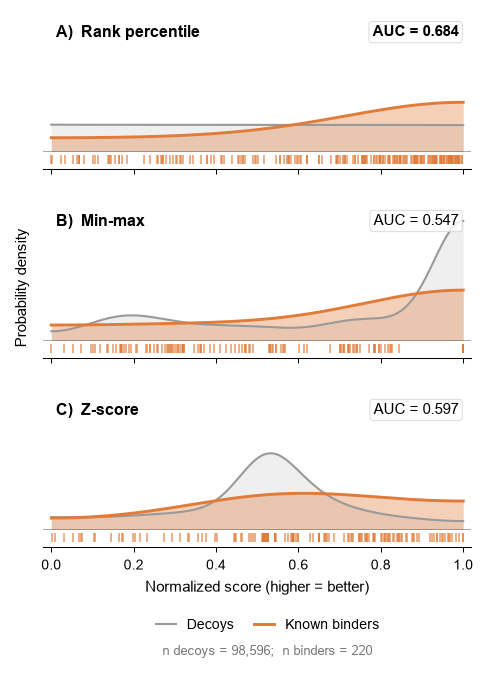


Saved PNG / PDF / SVG in C:\Users\antonio\Desktop\guild_publication\review\figures_regenerated


In [4]:

import matplotlib as mpl
from kde_helpers import kde_curve_bounded
from sklearn.metrics import roc_auc_score

# ── Publication-ready defaults (double-column manuscript) ─────────────────────
mpl.rcParams.update(mpl.rcParamsDefault)
mpl.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
    "font.size": 7,
    "axes.titlesize": 8,
    "axes.titleweight": "bold",
    "axes.labelsize": 7,
    "xtick.labelsize": 6.5,
    "ytick.labelsize": 6.5,
    "legend.fontsize": 6.5,
    "axes.linewidth": 0.5,
    "xtick.major.width": 0.5,
    "ytick.major.width": 0.5,
    "xtick.major.size": 2.5,
    "ytick.major.size": 2.5,
    "xtick.direction": "out",
    "ytick.direction": "out",
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "savefig.transparent": False,
    "figure.dpi": 150,
})

# ── Sample sizes ──────────────────────────────────────────────────────────────
plot_decoys  = unified[unified["group"] == "decoy"]
plot_binders = unified[unified["group"] == "known-binder"]
N_DECOYS  = len(plot_decoys)
N_BINDERS = len(plot_binders)

# ── Helper functions ──────────────────────────────────────────────────────────
def _auc(decoy_vals, kb_vals):
    y_true  = np.concatenate([np.zeros(len(decoy_vals)), np.ones(len(kb_vals))])
    y_score = np.concatenate([decoy_vals, kb_vals])
    mask    = ~np.isnan(y_score)
    if mask.sum() < 2 or len(np.unique(y_true[mask])) < 2:
        return float("nan")
    return roc_auc_score(y_true[mask], y_score[mask])

# Scores plotted so HIGHER = BETTER; rp_vina_score is stored 0 = best, so it's
# flipped here only for the plot (stored column untouched) -- not cosmetic:
# roc_auc_score treats a higher score as more likely positive.
guild_decoy = (1 - plot_decoys["rp_vina_score"]).dropna()
guild_kb    = (1 - plot_binders["rp_vina_score"]).dropna()
# vina_min_max (_minmax_invert) and zscore_norm (cdf(-z)) are already
# higher-is-better by construction, so this is the only inversion in this cell.
norm_decoy  = plot_decoys["vina_min_max"].dropna()
norm_kb     = plot_binders["vina_min_max"].dropna()
zsc_decoy   = plot_decoys["zscore_norm"].dropna()
zsc_kb      = plot_binders["zscore_norm"].dropna()

# (decoy_vals, kb_vals, panel_title, is_highlight)
panels = [
    (guild_decoy, guild_kb, "Rank percentile",             True),
    (norm_decoy,  norm_kb,  "Min-max",                     False),
    (zsc_decoy,   zsc_kb,   "Z-score",                     False),
]

panel_labels = ["A)", "B)", "C)"]

# kde_curve_bounded makes each curve integrate to 1 on its own bounded support;
# the shared y-scale (kmax) is kept for cross-panel comparability (see print below).
x_grid = np.linspace(0, 1, 400)
kmax = max(
    *(kde_curve_bounded(d, x_grid).max() for d, _, _, _ in panels),
    *(kde_curve_bounded(k, x_grid).max() for _, k, _, _ in panels),
    1e-9,
)
print("Figure 3 y-scale is SHARED across all three panels (kmax = "
      f"{kmax:.3f}) for cross-panel comparability -- a taller curve in one "
      "panel really is denser, not an artefact of a per-panel rescale.")

# ── 3×1 vertical figure ─────────────────────────────────────────────────────
fig, axes = plt.subplots(
    3, 1,
    figsize=(3.4, 4.8),
    sharex=True,
    sharey=True,
    gridspec_kw={"hspace": 0.22},
)

print(f"Rug ticks: known-binder rug is the complete set (n={N_BINDERS}); decoy "
      f"density (n={N_DECOYS:,}) is shown by the curve alone, not by a rug -- "
      "the binder rug is a per-molecule value, not a per-target value "
      "underlying the pooled distributions.")

print("\nAUCs (binder vs. decoy, higher = better on every panel's axis):")
for (dec_vals, kb_vals, title, _highlight) in panels:
    print(f"  {title:<16s} AUC = {_auc(dec_vals.values, kb_vals.values):.3f}")

for idx, (ax, (dec_vals, kb_vals, title, highlight)) in enumerate(zip(axes, panels, strict=False)):
    kd = kde_curve_bounded(dec_vals, x_grid)
    kb = kde_curve_bounded(kb_vals,  x_grid)

    # KDE fills + lines
    ax.fill_between(x_grid, 0, kd, color=COLORS["decoy"],        alpha=0.15, linewidth=0)
    ax.plot(x_grid, kd, color=COLORS["decoy"],        lw=1.0, label="Decoys")
    ax.fill_between(x_grid, 0, kb, color=COLORS["known-binder"], alpha=0.35, linewidth=0)
    ax.plot(x_grid, kb, color=COLORS["known-binder"], lw=1.4, label="Known binders")

    # Zero line
    ax.axhline(0, color="black", lw=0.4, alpha=0.4)

    # Rug: binders -- every known binder, no subsampling
    for v in kb_vals:
        ax.plot([v, v], [-kmax*0.03, -kmax*0.11], color=COLORS["known-binder"],
                lw=0.8, alpha=0.70, solid_capstyle="butt")

    # Panel label + title (top-left)
    ax.text(
        0.03, 0.93, f"{panel_labels[idx]}  {title}",
        transform=ax.transAxes, fontsize=7.5, fontweight="bold",
        va="top", ha="left",
    )

    # AUC annotation (top-right) — bold only for rank percentile (panel A)
    auc = _auc(dec_vals.values, kb_vals.values)
    auc_weight = "bold" if highlight else "normal"
    ax.text(
        0.97, 0.93, f"AUC = {auc:.3f}",
        transform=ax.transAxes, fontsize=7, fontweight=auc_weight,
        va="top", ha="right",
        bbox=dict(boxstyle="round,pad=0.25", facecolor="white",
                  edgecolor="#cccccc", alpha=0.85, linewidth=0.4),
    )

    # Axes cosmetics
    ax.set_xlim(-0.02, 1.02)
    ax.set_ylim(-kmax * 0.15, kmax * 1.15)
    ax.tick_params(axis="y", left=False, labelleft=False)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_visible(False)

    if idx < 2:
        ax.tick_params(axis="x", labelbottom=False)
    else:
        # Explicit "(higher = better)" rather than bare "Normalized score" --
        # see the inversion note above the panels list.
        ax.set_xlabel("Normalized score (higher = better)", labelpad=4)

# Shared legend below the bottom panel
legend_handles = [
    Line2D([0], [0], color=COLORS["decoy"],        lw=1.0, label="Decoys"),
    Line2D([0], [0], color=COLORS["known-binder"], lw=1.4, label="Known binders"),
]
fig.legend(
    handles=legend_handles,
    loc="lower center",
    ncol=2,
    bbox_to_anchor=(0.5, 0.005),
    frameon=False,
    columnspacing=1.5,
    handlelength=1.5,
)

# "Probability density" rather than bare "Density": each curve integrates to 1
# on its own bounded [0, 1] support (kde_curve_bounded). Shared scale stated above.
fig.text(
    0.005, 0.5, "Probability density",
    va="center", ha="left", rotation="vertical", fontsize=7,
)
fig.subplots_adjust(left=0.06, bottom=0.14)

# Sample size annotation
fig.text(
    0.5, -0.01,
    f"n decoys = {N_DECOYS:,};  n binders = {N_BINDERS:,}",
    ha="center", fontsize=6, color="#777777",
)

# Save in multiple formats
for ext in ("png", "pdf", "svg"):
    out = OUT_DIR / f"figure_3_validation_three_normalisations.{ext}"
    fig.savefig(out, dpi=600, bbox_inches="tight")

plt.show()
print(f"\nSaved PNG / PDF / SVG in {OUT_DIR}")


## Property-matched decoy panel and descriptor-only control

Figure 3's decoys are not property-matched to the known binders: on the 3-target rerun,
actives average 445 Da vs decoys' 353 Da, and a heavy-atom-count baseline alone reaches
AUC 0.865 -- higher than any docking method -- collapsing to 0.645 once size-matched.
This cell adds that control: a decoy panel matched to each target's binders (molecular
weight, cLogP, HBD, HBA, rotatable bonds, net charge; ECFP4 Tanimoto < 0.35 to every
binder so a match isn't a close analogue), plus a descriptor-only baseline using no
docking score at all.

`guild.tools.decoy_matching` (tested in `tests/ligand_properties/test_decoy_matching.py`)
implements the matching and descriptor-only baseline as reusable functions, run below over
the full pool (131 targets, 655 binders, 133,000 candidate decoys): 9,910 property-matched,
structurally-distinct decoys kept; descriptor-only AUCs 0.45-0.73 (molecular weight highest
at 0.732); combined-descriptor AUC 0.738 -- both close to, not far below, Figure 3's
rank-percentile AUC (0.684), a smaller margin than a 5-target demo slice suggested. Figure 3
repeated on exactly these 9,910 matched decoys (same 220 binders) drops to AUC 0.588
(rank percentile), 0.451 (min-max), 0.588 (z-score) -- saved separately as
`figure_3_matched_decoys.{png,pdf,svg}`, not overwriting the unmatched figure above.

In [5]:
# assign_properties reports tqdm progress; silenced here so committing real
# outputs doesn't bloat the notebook with hundreds of tqdm's own progress-bar frames.
import guild.tools.ligand_properties as _ligand_properties
from guild.tools.decoy_matching import (
    combined_descriptor_auc,
    descriptor_only_auc,
    match_decoys_to_binders,
)

_ligand_properties.tqdm = lambda iterable, **kwargs: iterable

# Full pool, every target -- several minutes (see markdown above for the cost).
N_TARGETS_FOR_DEMO = None

kb_for_matching = kb_scores.dropna(subset=["smiles"]).copy()
decoys_for_matching = pd.read_csv(COMBINED_SCORES_PATH, sep="\t").rename(columns=LEGACY_RENAME)
decoys_for_matching = decoys_for_matching[decoys_for_matching["ligand_category"] == "decoy"]
decoys_for_matching = decoys_for_matching.dropna(subset=["smiles"]).copy()

if N_TARGETS_FOR_DEMO is not None:
    demo_targets = kb_for_matching["protein_config_id"].unique()[:N_TARGETS_FOR_DEMO]
    kb_for_matching = kb_for_matching[kb_for_matching["protein_config_id"].isin(demo_targets)]
    decoys_for_matching = decoys_for_matching[decoys_for_matching["protein_config_id"].isin(demo_targets)]

print(f"Matching against {kb_for_matching['protein_config_id'].nunique()} target(s): "
      f"{len(kb_for_matching)} binders, {len(decoys_for_matching):,} candidate decoys")

matched_decoys = match_decoys_to_binders(kb_for_matching, decoys_for_matching)
print(f"Property-matched, structurally-distinct decoys kept: {len(matched_decoys)}")

print("\nDescriptor-only baseline (no docking score), per descriptor:")
print(descriptor_only_auc(kb_for_matching, decoys_for_matching).to_string(index=False))

print(f"\nCombined-descriptor logistic-regression AUC (cross-validated): "
      f"{combined_descriptor_auc(kb_for_matching, decoys_for_matching, n_splits=3):.3f}")

print(
    "\nTo render the matched Figure 3 panel: set DECOY_SUBSET above to a "
    "predicate over (protein_config_id, ligand_id) pairs from matched_decoys -- NOT "
    "ligand_id alone (this pool has ~1,000 unique decoys each docked against ~133 "
    "targets, so a ligand_id-only filter readmits every target-row for any decoy "
    "matched anywhere) -- and re-run this notebook from the top."
)


Matching against 131 target(s): 655 binders, 133,000 candidate decoys


Property-matched, structurally-distinct decoys kept: 9910

Descriptor-only baseline (no docking score), per descriptor:


       descriptor      auc
 molecular_weight 0.731766
             logp 0.669523
            n_hba 0.453460
            n_hbd 0.558380
n_rotatable_bonds 0.664202
       net_charge 0.516288



Combined-descriptor logistic-regression AUC (cross-validated): 0.738

To render the matched Figure 3 panel: set DECOY_SUBSET above to a predicate over (protein_config_id, ligand_id) pairs from matched_decoys -- NOT ligand_id alone (this pool has ~1,000 unique decoys each docked against ~133 targets, so a ligand_id-only filter readmits every target-row for any decoy matched anywhere) -- and re-run this notebook from the top.
